# EDa

In [1]:
6+6

12

In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../dataset/data.csv')
print(df.shape)
#df = df.head(1000)
df

(39942, 5)


,label,title,text,subject,date
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...,...
39937,0,THIS IS NOT A JOKE! Soros-Linked Group Has Pla...,"The Left has been organizing for decades, and ...",left-news,"Sep 22, 2016"
39938,0,THE SMARTEST WOMAN In Politics: “How Trump Can...,Monica Crowley offers some of the most brillia...,left-news,"Sep 22, 2016"
39939,0,BREAKING! SHOCKING VIDEO FROM CHARLOTTE RIOTS:...,Protest underway in Charlotte: Things got com...,left-news,"Sep 21, 2016"
39940,0,BREAKING! Charlotte News Station Reports Cops ...,"Local Charlotte, NC news station WSOCTV is rep...",left-news,"Sep 21, 2016"


## 1. Data Exploration


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39942 entries, 0 to 39941
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    39942 non-null  int64
 1   title    39942 non-null  str  
 2   text     39942 non-null  str  
 3   subject  39942 non-null  str  
 4   date     39942 non-null  str  
dtypes: int64(1), str(4)
memory usage: 96.7 MB


In [5]:
print("Shape:", df.shape)
print("\nMissing values: ", df.isnull().sum().sum())
df.info()


Shape: (39942, 5)

Missing values:  0
<class 'pandas.DataFrame'>
RangeIndex: 39942 entries, 0 to 39941
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    39942 non-null  int64
 1   title    39942 non-null  str  
 2   text     39942 non-null  str  
 3   subject  39942 non-null  str  
 4   date     39942 non-null  str  
dtypes: int64(1), str(4)
memory usage: 96.7 MB


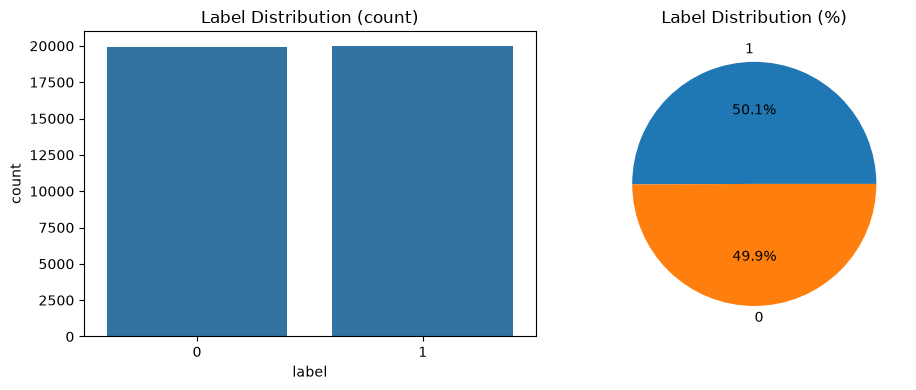

In [6]:
# --- Label distribution ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x='label', data=df, ax=ax[0])
ax[0].set_title('Label Distribution (count)')

df['label'].value_counts(normalize=True).plot.pie(
    autopct='%1.1f%%', ax=ax[1], ylabel=''
)
ax[1].set_title('Label Distribution (%)')

plt.tight_layout()
plt.show()


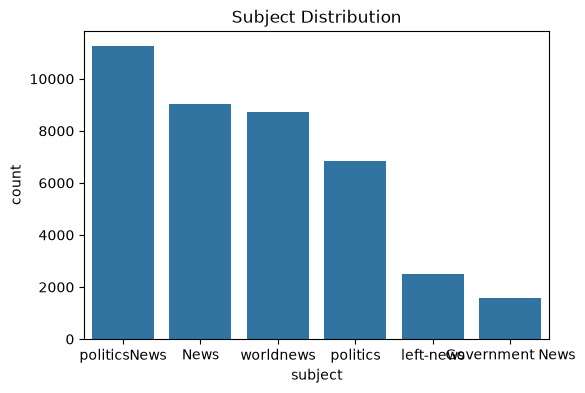

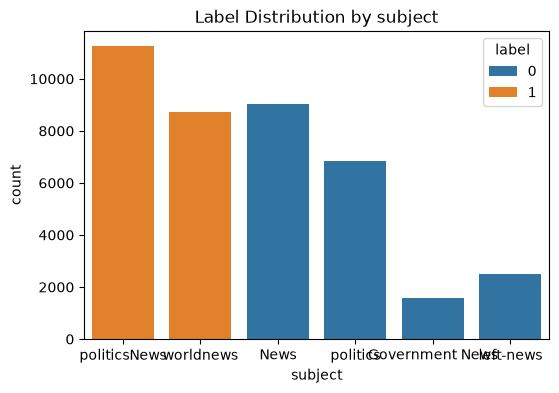

In [7]:
# --- Categorical column distribution (e.g. subject) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='subject', data=df, order=df['subject'].value_counts().index)
plt.title('Subject Distribution')
plt.show()

# Label distribution across categories — useful to spot imbalance/bias per group
plt.figure(figsize=(6, 4))
sns.countplot(x='subject', hue='label', data=df)
plt.title('Label Distribution by subject')
plt.show()


In [7]:
df['subject'].value_counts()

subject
politicsNews       11272
News                9050
worldnews           8727
politics            6841
left-news           2482
Government News     1570
Name: count, dtype: int64

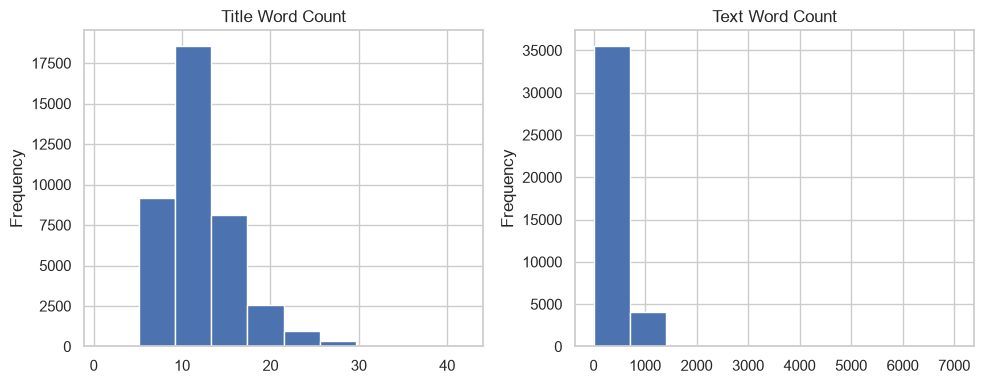

In [ ]:
# --- Text length distribution (quick sanity check per text column) ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

df['title'].str.split().apply(len).plot.hist(ax=ax[0], bins=10)
ax[0].set_title('Title Word Count')

df['text'].str.split().apply(len).plot.hist(ax=ax[1], bins=10)
ax[1].set_title('Text Word Count')

plt.tight_layout()
plt.show()


label,0,1
subject,,
Government News,1570,0
News,9050,0
left-news,2482,0
politics,6841,0
politicsNews,0,11272
worldnews,0,8727


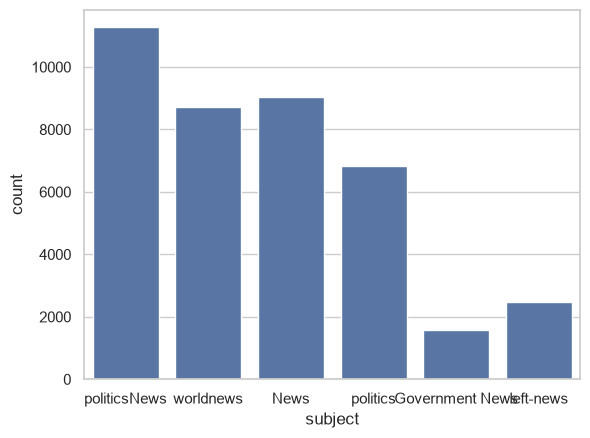

In [ ]:
sns.countplot(x='subject', data=df)
pd.crosstab(df['subject'], df['label']) 

In [8]:
df.corr()

ValueError: could not convert string to float: 'As U.S. budget fight looms, Republicans flip their fiscal script'

<Axes: xlabel='date'>

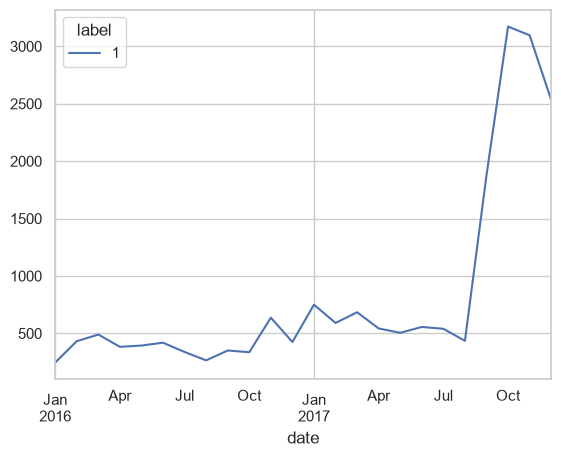

In [ ]:

#--- Date distribution ---
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.groupby(df['date'].dt.to_period('M'))['label'].value_counts().unstack().plot()


In [ ]:
df.groupby(df['date'].dt.to_period('M'))['label'].value_counts()

date     label
2016-01  1         246
2016-02  1         432
2016-03  1         490
2016-04  1         383
2016-05  1         394
2016-06  1         419
2016-07  1         338
2016-08  1         265
2016-09  1         351
2016-10  1         336
2016-11  1         637
2016-12  1         425
2017-01  1         750
2017-02  1         591
2017-03  1         684
2017-04  1         543
2017-05  1         505
2017-06  1         556
2017-07  1         540
2017-08  1         435
2017-09  1        1878
2017-10  1        3172
2017-11  1        3096
2017-12  1        2533
Name: count, dtype: int64

<Axes: xlabel='text_len', ylabel='Count'>

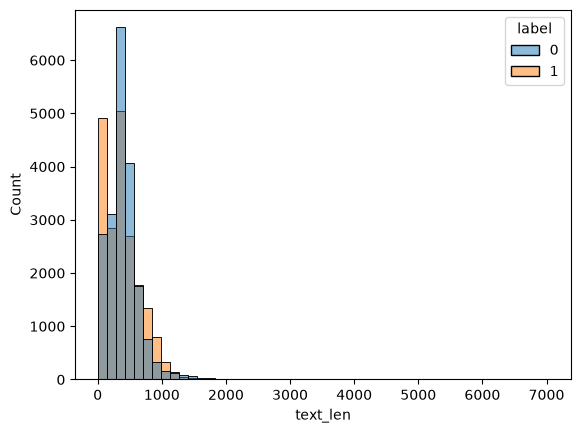

In [26]:

#--- Text length per label ---
df['text_len'] = df['text'].str.split().apply(len)
sns.histplot(data=df, x='text_len', hue='label', bins=50)

In [ ]:
# df.shape, df.info(), df.isnull().sum(), df.duplicated().sum()

# --- Label distribution ---
# sns.countplot(x='label', data=df)

# --- Subject distribution & leakage check ---
# sns.countplot(x='subject', data=df)
# pd.crosstab(df['subject'], df['label'])   # <-- IMPORTANT: check if subject perfectly separates classes

# --- Date distribution ---
# df['date'] = pd.to_datetime(df['date'], errors='coerce')
# df.groupby(df['date'].dt.to_period('M'))['label'].value_counts().unstack().plot()

# --- Text length per label ---
# df['text_len'] = df['text'].str.split().apply(len)
# sns.histplot(data=df, x='text_len', hue='label', bins=50)

In [9]:
df['date'].value_counts()

date
December 20, 2017                                                                                                           182
December 6, 2017                                                                                                            166
November 30, 2017                                                                                                           162
November 9, 2017                                                                                                            158
October 13, 2017                                                                                                            155
                                                                                                                           ... 
Apr 1, 2015                                                                                                                   1
Sep 10, 2015                                                                                       

Unparseable dates: 19943


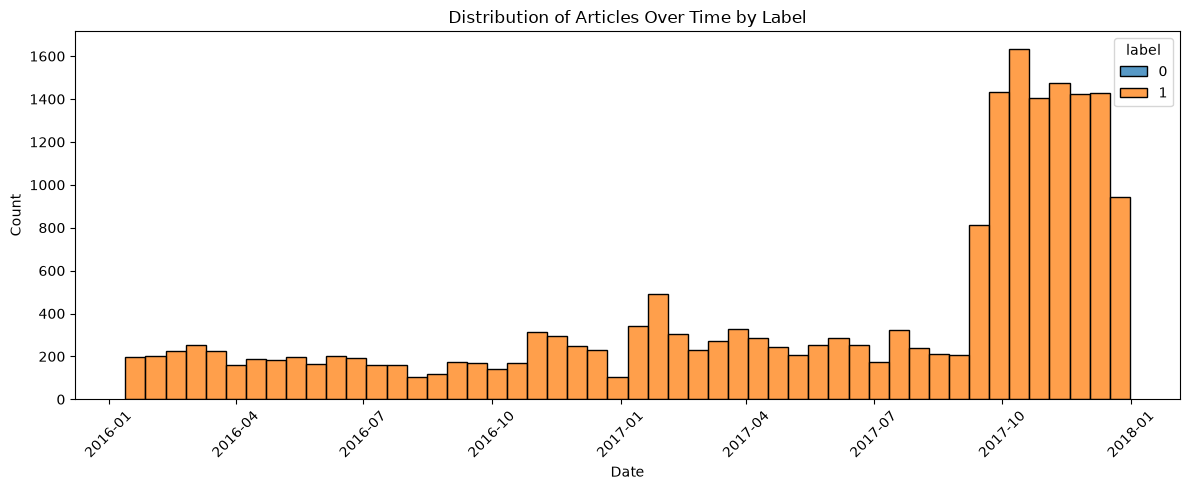

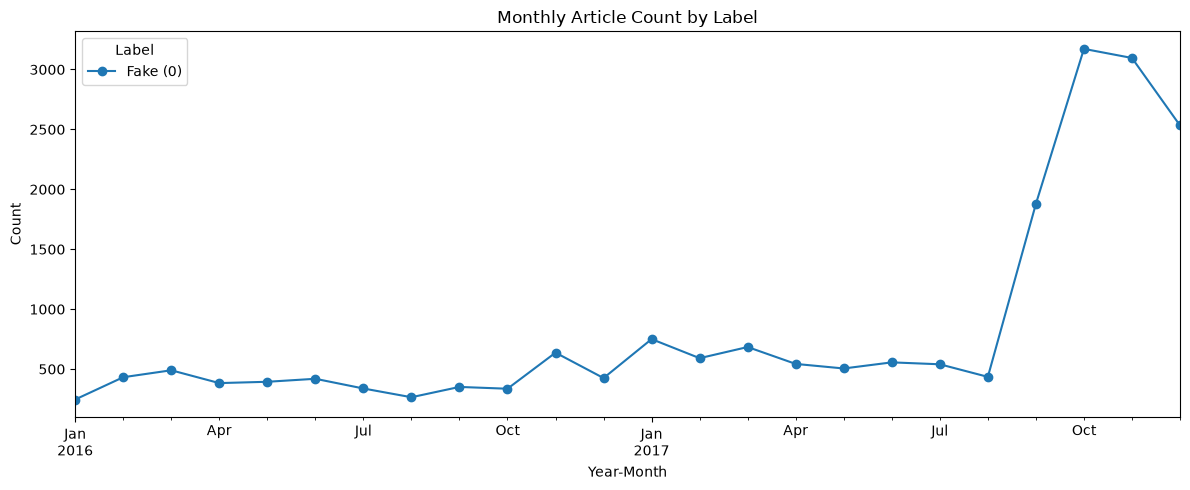

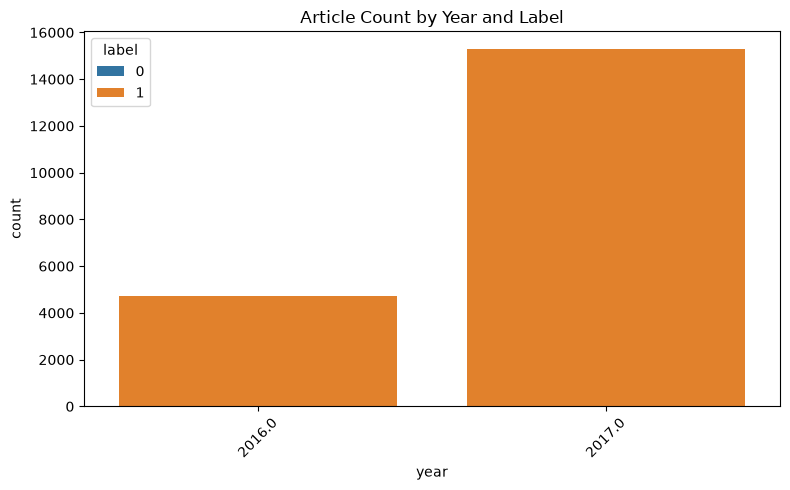

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Convert string date to datetime ---
# errors='coerce' turns unparseable dates into NaT instead of raising an error
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Check how many dates failed to parse (worth inspecting these rows)
print("Unparseable dates:", df['date'].isna().sum())

# Optional: extract useful sub-features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M')

# --- 2. Plot date distribution by label ---

# A) Histogram of raw dates, split by label
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='date', hue='label', bins=50, multiple='stack')
plt.title('Distribution of Articles Over Time by Label')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# B) Monthly counts per label (often clearer than raw daily histogram)
monthly_counts = df.groupby(['year_month', 'label']).size().unstack(fill_value=0)

monthly_counts.plot(kind='line', figsize=(12, 5), marker='o')
plt.title('Monthly Article Count by Label')
plt.xlabel('Year-Month')
plt.ylabel('Count')
plt.legend(title='Label', labels=['Fake (0)', 'Real (1)'])
plt.tight_layout()
plt.show()

# C) Yearly distribution (simpler view, good for spotting date-based leakage)
plt.figure(figsize=(8, 5))
sns.countplot(x='year', hue='label', data=df)
plt.title('Article Count by Year and Label')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
df[df['date'].isna()]['label'].value_counts()

label
0    19943
Name: count, dtype: int64

# comments
- Drop subject
  - clear distinction between the labels. Some subjects clearly predict the label. so there is data leak
- Drop date
  - not relavent
  - some dates not convertable
  - keep empty text for now ---> later come to it
    - keep the columns and fill with empty strings - this might also contain info
    - example - all text with len == 0 --> fake news (only 1 real news)
    - - all title with len == 1 --> fake news (mostly links)

In [18]:
df[df[['title', 'text']].duplicated()]

,label,title,text,subject,date,year,month,year_month
445,1,Senate tax bill stalls on deficit-focused 'tri...,WASHINGTON (Reuters) - The U.S. Senate on Thur...,politicsNews,2017-11-30,2017.0,11.0,2017-11
778,1,Trump warns 'rogue regime' North Korea of grav...,BEIJING (Reuters) - U.S. President Donald Trum...,politicsNews,2017-11-08,2017.0,11.0,2017-11
892,1,"Republicans unveil tax cut bill, but the hard ...",WASHINGTON (Reuters) - U.S. House of Represent...,politicsNews,2017-11-02,2017.0,11.0,2017-11
896,1,Trump taps Fed centrist Powell to lead U.S. ce...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,2017-11-02,2017.0,11.0,2017-11
974,1,"Two ex-Trump aides charged in Russia probe, th...",WASHINGTON (Reuters) - Federal investigators p...,politicsNews,2017-10-30,2017.0,10.0,2017-10
...,...,...,...,...,...,...,...,...
39936,0,YIKES! Tomi Lahren DEMOLISHES Hillary: “How Da...,Wow! Bravo Tomi! You really nailed it this tim...,left-news,NaT,NaN,NaN,NaT
39937,0,THIS IS NOT A JOKE! Soros-Linked Group Has Pla...,"The Left has been organizing for decades, and ...",left-news,NaT,NaN,NaN,NaT
39938,0,THE SMARTEST WOMAN In Politics: “How Trump Can...,Monica Crowley offers some of the most brillia...,left-news,NaT,NaN,NaN,NaT
39940,0,BREAKING! Charlotte News Station Reports Cops ...,"Local Charlotte, NC news station WSOCTV is rep...",left-news,NaT,NaN,NaN,NaT


In [8]:
#--- Text length per label ---
df['text_len'] = df['text'].str.split().apply(len)
df['title_len'] = df['title'].str.split().apply(len)
df

,label,title,text,subject,date,text_len,title_len
0,1,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",749,10
1,1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",624,9
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",457,10
3,1,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",376,9
4,1,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",852,11
...,...,...,...,...,...,...,...
39937,0,THIS IS NOT A JOKE! Soros-Linked Group Has Pla...,"The Left has been organizing for decades, and ...",left-news,"Sep 22, 2016",841,20
39938,0,THE SMARTEST WOMAN In Politics: “How Trump Can...,Monica Crowley offers some of the most brillia...,left-news,"Sep 22, 2016",791,15
39939,0,BREAKING! SHOCKING VIDEO FROM CHARLOTTE RIOTS:...,Protest underway in Charlotte: Things got com...,left-news,"Sep 21, 2016",26,12
39940,0,BREAKING! Charlotte News Station Reports Cops ...,"Local Charlotte, NC news station WSOCTV is rep...",left-news,"Sep 21, 2016",380,18


In [20]:
df.text_len.value_counts()

text_len
0       610
403     147
402     140
406     131
405     126
       ... 
2470      1
1383      1
4149      1
1202      1
1336      1
Name: count, Length: 1454, dtype: int64

In [47]:
df[df['text_len'] < 10]#['label'].value_counts()

,label,title,text,subject,date,text_len,title_len
8970,1,Graphic: Supreme Court roundup,,politicsNews,"June 16, 2016",0,4
29357,0,https://100percentfedup.com/served-roy-moore-v...,https://100percentfedup.com/served-roy-moore-v...,politics,https://100percentfedup.com/served-roy-moore-v...,1,1
30922,0,TAKE OUR POLL: Who Do You Think President Trum...,,politics,"May 10, 2017",0,15
31040,0,Joe Scarborough BERATES Mika Brzezinski Over “...,,politics,"Apr 26, 2017",0,19
31116,0,MY FAVORITE EXCUSES…Featuring Hillary Rotten C...,Enjoy:,politics,"Apr 17, 2017",1,7
...,...,...,...,...,...,...,...
39866,0,UNREAL! OBAMA BLAMES SYRIAN CIVIL WAR ON CLIMA...,,left-news,"Oct 5, 2016",0,15
39894,0,WHAT WAS HE THINKING? DISHEVELED OBAMA YELLS F...,,left-news,"Oct 1, 2016",0,17
39898,0,MUSLIM WOMAN BUSTED Buying Soda With Food Stam...,,left-news,"Sep 29, 2016",0,17
39902,0,IS OUR FIRST AMENDMENT RIGHT Being Stolen By T...,***WARNING***This video is GRAPHIC!***,left-news,"Sep 29, 2016",4,29


<Axes: xlabel='text_len', ylabel='Count'>

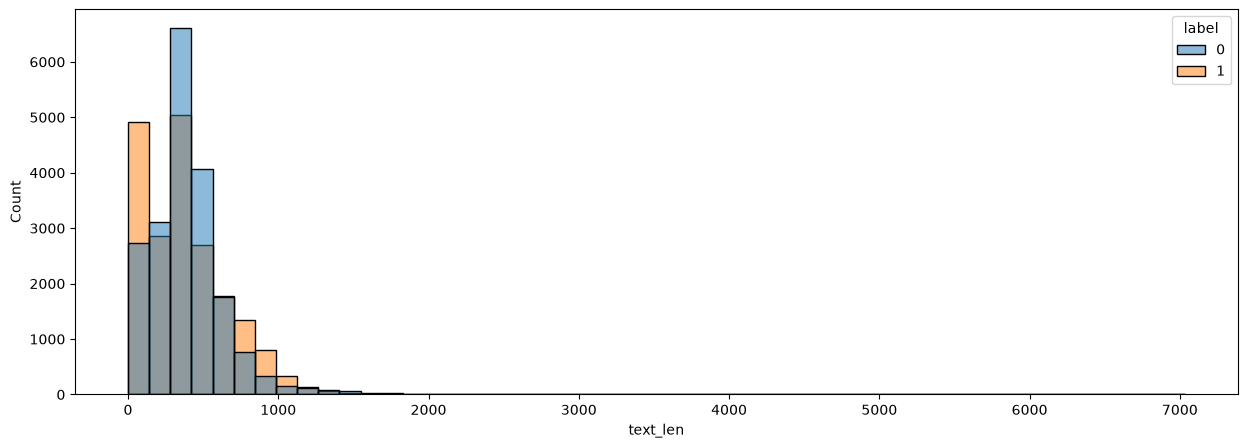

In [18]:
plt.figure(figsize=(15, 5))
sns.histplot(data=df, x='text_len', hue='label', bins=50)

In [44]:
df[df['title_len'] == 1]#['label'].value_counts()

,label,title,text,subject,date,text_len,title_len
29357,0,https://100percentfedup.com/served-roy-moore-v...,https://100percentfedup.com/served-roy-moore-v...,politics,https://100percentfedup.com/served-roy-moore-v...,1,1
35506,0,https://100percentfedup.com/video-hillary-aske...,https://100percentfedup.com/video-hillary-aske...,politics,https://100percentfedup.com/video-hillary-aske...,1,1
35507,0,https://100percentfedup.com/12-yr-old-black-co...,https://100percentfedup.com/12-yr-old-black-co...,politics,https://100percentfedup.com/12-yr-old-black-co...,1,1
35838,0,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,https://fedup.wpengine.com/wp-content/uploads/...,1,1
35839,0,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,politics,https://fedup.wpengine.com/wp-content/uploads/...,1,1
37431,0,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...,1,1
37432,0,https://fedup.wpengine.com/wp-content/uploads/...,https://fedup.wpengine.com/wp-content/uploads/...,Government News,https://fedup.wpengine.com/wp-content/uploads/...,1,1
38932,0,Homepage,[vc_row][vc_column width= 1/1 ][td_block_trend...,left-news,MSNBC HOST Rudely Assumes Steel Worker Would N...,53,1


In [46]:
df.iloc[38932,2]

'[vc_row][vc_column width= 1/1 ][td_block_trending_now limit= 5 ][td_block_big_grid sort= featured ][/vc_column][/vc_row][vc_row] [vc_column width= 2/3 ][td_block_5 limit= 24  custom_title= HOT OFF THE PRESS!  td_filter_default_txt= All  ajax_pagination= load_more  border_top= no_border_top ] [/vc_column][vc_column width= 1/3 ][vc_widget_sidebar sidebar_id= td-default ][/vc_column] [/vc_row][vc_row][vc_column width= 1/1 ][td_block_14 limit= 3  custom_title= EVEN MORE NEWS  td_filter_default_txt= All  ajax_pagination= next_prev  header_color= #288abf ][/vc_column] [/vc_row]'

<Axes: xlabel='title_len', ylabel='Count'>

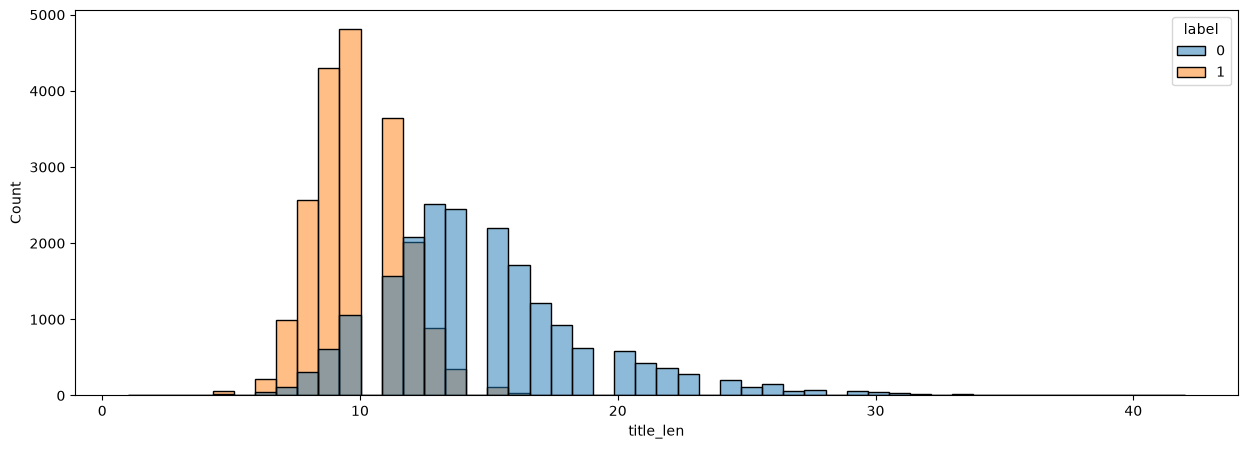

In [19]:
plt.figure(figsize=(15, 5))
sns.histplot(data=df, x='title_len', hue='label', bins=50)